In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.executable

'/usr/bin/python3'

In [0]:
import numpy as np
import random

class_1 = [6,15] + 6*np.random.randn(100,2)
label_1 = np.ones(100)
class_2 = [18,3] + 6*np.random.randn(100,2)
label_2 = np.ones(100)-2

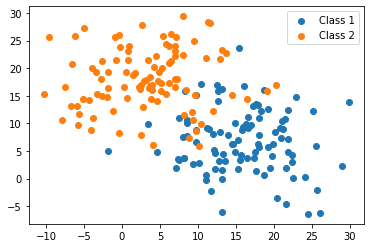

In [6]:
plt.scatter(class_1[:,1],class_1[:,0])
plt.scatter(class_2[:,1],class_2[:,0])

plt.legend(('Class 1', 'Class 2'))

In [0]:
X = np.vstack([class_1,class_2])
y = np.vstack([label_1.reshape(100,1),label_2.reshape(100,1)])

mapIndexPosition = list(zip(X, y))
random.shuffle(mapIndexPosition)
X_, y_ = zip(*mapIndexPosition)
y_ = np.array(y_)
X_ = np.array(X_)

In [0]:
class_wise_means = {}
for class_ in list(set(y_[:,0])):
  class_wise_means[class_] = {}
  class_wise_means[class_]['no_samples'] = len(X_[y[:,0]==class_])
  class_wise_means[class_]['mean'] = X_[y[:,0]==class_].mean(axis=0)

overall_mean = X_.mean(axis=0)

$S_B = \sum_{i=1}^{C} N_i (\mu_i - \mu) (\mu_i - \mu)^T$ 

In [0]:
S_B = np.zeros((X_.shape[1], X_.shape[1]))

print_rank = False

for class_ in class_wise_means.keys():
  temp = class_wise_means[class_]['mean'] - overall_mean
  matrix = np.outer(temp, temp)
  if print_rank:
    print(np.linalg.matrix_rank(matrix))
  S_B += class_wise_means[class_]['no_samples']*matrix

$S_B$ is the sum of C rank one matrix ,that is why at max its rank can be C-1

In [56]:
print('rank of between class scatter matrix:',np.linalg.matrix_rank(S_B)," Matrix:",S_B)

rank of between class scatter matrix: 1  Matrix: [[259.82329223 -22.94462364]
 [-22.94462364   2.02620693]]


$S_w = \sum_{i=1}^{N} (x_i - \mu_{y_i}) (x_i - \mu_{y_i})^T$ 

In [0]:
S_W = np.zeros((X_.shape[1], X_.shape[1]))
for i in range(X_.shape[0]):
  temp = X_[i] - class_wise_means[y_[i][0]]['mean']
  S_W += np.outer(temp, temp)

In [54]:
print('rank of within class scatter matrix:',np.linalg.matrix_rank(S_W)," Matrix:",S_W)

rank of within class scatter matrix: 2  Matrix: [[10142.89520898 -5508.92174395]
 [-5508.92174395 14548.88570363]]


In [0]:
mat = np.dot(np.linalg.pinv(S_W), S_B)

In [0]:
eigvals, eigvecs = np.linalg.eig(mat)

In [0]:
eigvecs = eigvecs[:,np.argsort(eigvals)[::-1]]

w = np.array([eigvecs[i][1] for i in range(len(list(class_wise_means.keys())))])

In [67]:
np.dot(w,X_.T)

array([-1.33525332, 17.52209955, 11.03495331,  9.87276698, -0.16318988,
        1.06419315, 11.66957111, 10.99585166,  4.95734667, -4.65416809,
       20.30659477,  8.39734315, -5.53740994, 13.32807774,  3.14717412,
       -0.63897804,  5.09489296, -4.7830829 ,  8.7584368 ,  5.19207778,
        3.86854355, -3.8212029 , 12.62480302,  7.67215487, 17.69793322,
        7.18745374,  8.0649347 ,  9.4501038 ,  6.49815141,  5.8309397 ,
       18.62381698, 25.39639436, 12.25114085, 22.52080398, 21.57762058,
       11.06172935, 14.01107855,  5.34190866, 15.75825583, 30.95495076,
       21.90864802, -1.91253302, 17.58584057, -2.63862918,  9.3379928 ,
        1.27031939, 22.94026805, 23.84968107, 15.79275086, 20.06195542,
       -0.37270115, 18.44225207, 13.00776292,  9.50971082,  4.61500722,
        8.47985643, 18.41407126, 15.70152968, 16.77239294, 17.34630665,
        3.8250965 , -3.23511588, 20.08036657, 21.68498045,  7.62425805,
       -0.74410458, 25.3695379 , -1.24498713, 12.02636648, 22.36